In [1]:
!pip install pandas numpy scikit-learn torch onnx onnxruntime matplotlib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 10.6 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = '/content/drive/My Drive/penguins.csv'  # choose penguins.csv when prompted

Mounted at /content/drive


Training done.
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        29
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.99      0.98      0.98        67
weighted avg       0.99      0.99      0.98        67

Weighted F1 = 0.985


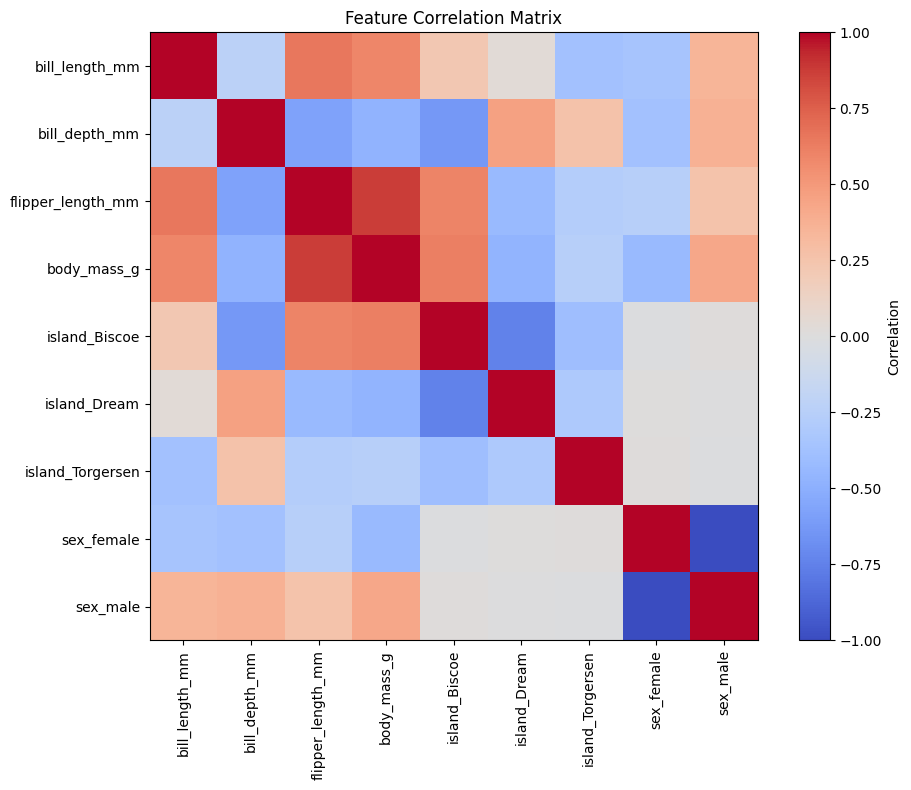

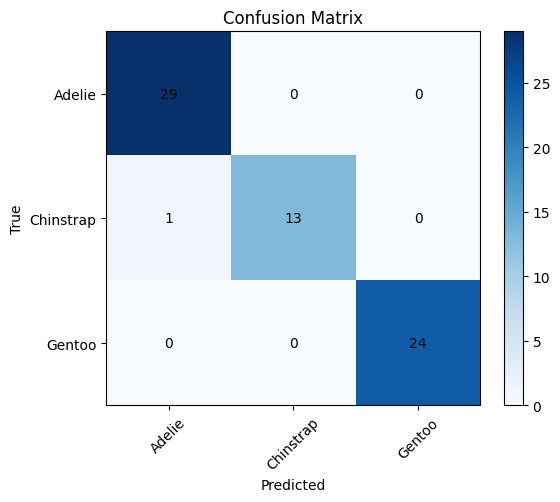

✅ Exported: onnx_output/penguins_model.onnx
Artifacts saved.


/tmp/ipython-input-678704515.py:92: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(model, dummy, onnx_path, input_names=['input'], output_names=['output'],


In [5]:
import os, json, torch, torch.nn as nn, matplotlib.pyplot as plt
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ===== Load and preprocess =====
df = pd.read_csv(DATA_PATH).dropna().reset_index(drop=True)
target_col = "species" if "species" in df.columns else "Species"
y_raw = df[target_col].astype(str)
X_raw = df.drop(columns=[target_col])

# one-hot encode categoricals + scale
cat_cols = [c for c in X_raw.columns if not pd.api.types.is_numeric_dtype(X_raw[c])]
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=False)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_columns = X.columns.tolist()

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_.tolist()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2,
                                                    stratify=y, random_state=42)

# ===== Define and train a small MLP =====
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x): return self.net(x)

model = MLP(X_train.shape[1], len(class_names))
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

X_t = torch.tensor(X_train, dtype=torch.float32)
y_t = torch.tensor(y_train, dtype=torch.long)
for epoch in range(80):          # short, fast training
    opt.zero_grad()
    out = model(X_t)
    loss = loss_fn(out, y_t)
    loss.backward()
    opt.step()
print("Training done.")

# ===== Evaluate =====
model.eval()
with torch.no_grad():
    preds = model(torch.tensor(X_test, dtype=torch.float32))
    y_pred = torch.argmax(preds, dim=1).numpy()

print(classification_report(y_test, y_pred, target_names=class_names))
f1w = f1_score(y_test, y_pred, average='weighted')
print("Weighted F1 =", round(f1w,3))

# ===== Plot correlation matrix =====
plt.figure(figsize=(10,8))
corr = pd.DataFrame(X, columns=feature_columns).corr()
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.title("Feature Correlation Matrix")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

# ===== Plot confusion matrix =====
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ===== Export to ONNX =====
os.makedirs("onnx_output", exist_ok=True)
dummy = torch.randn(1, X_train.shape[1])
onnx_path = "onnx_output/penguins_model.onnx"
torch.onnx.export(model, dummy, onnx_path, input_names=['input'], output_names=['output'],
                  opset_version=11)
print("✅ Exported:", onnx_path)

# ===== Save artifacts =====
artifacts = {
    "feature_columns": feature_columns,
    "label_classes": class_names,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_var": scaler.var_.tolist()
}
with open("onnx_output/penguins_artifacts.json","w") as f:
    json.dump(artifacts,f)
print("Artifacts saved.")

In [6]:
from google.colab import files
files.download("onnx_output/penguins_model.onnx")
files.download("onnx_output/penguins_artifacts.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>